# graphical illustration of the transient growth phenomenon

## Time Evolution of State Norm for Different Initial Conditions

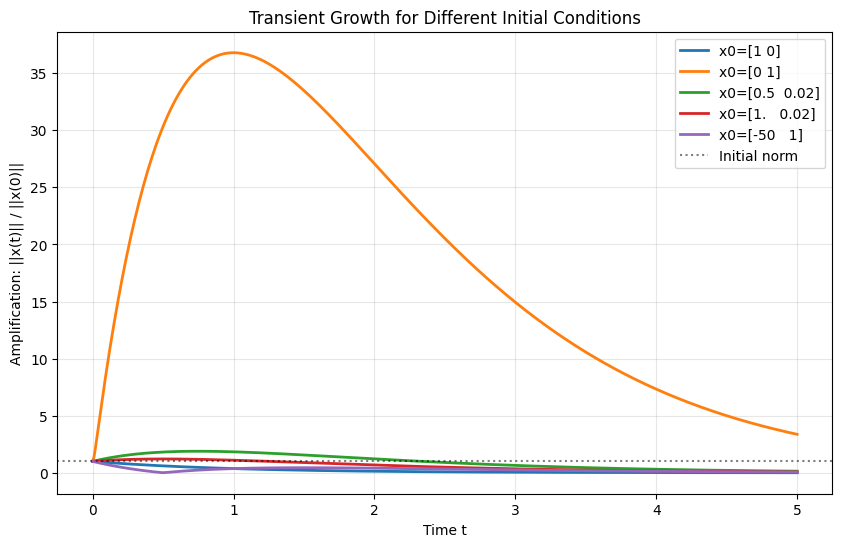

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# System matrix
A = np.array([[-1, 100], [0, -1]])

# Matrix exponential
def exp_At(t):
    return np.exp(-t) * np.array([[1, 100*t], [0, 1]])

# Time vector
t = np.linspace(0, 5, 500)

# Different initial conditions
initial_conditions = [
    np.array([1, 0]),      # x1-direction
    np.array([0, 1]),      # x2-direction
    np.array([0.5, 0.02]), # Near optimal for transient growth
    np.array([1, 0.02]),   # Another initial condition
    np.array([-50, 1])     # Shows growth then decay
]

# Plot norm evolution
plt.figure(figsize=(10, 6))
for i, x0 in enumerate(initial_conditions):
    norm_t = np.zeros_like(t)
    for j, tj in enumerate(t):
        x_t = exp_At(tj) @ x0
        norm_t[j] = np.linalg.norm(x_t)

    plt.plot(t, norm_t/np.linalg.norm(x0),
             label=f'x0={x0}', linewidth=2)

plt.axhline(y=1, color='k', linestyle=':', alpha=0.5, label='Initial norm')
plt.xlabel('Time t')
plt.ylabel('Amplification: ||x(t)|| / ||x(0)||')
plt.title('Transient Growth for Different Initial Conditions')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Maximum Amplification (Operator Norm)

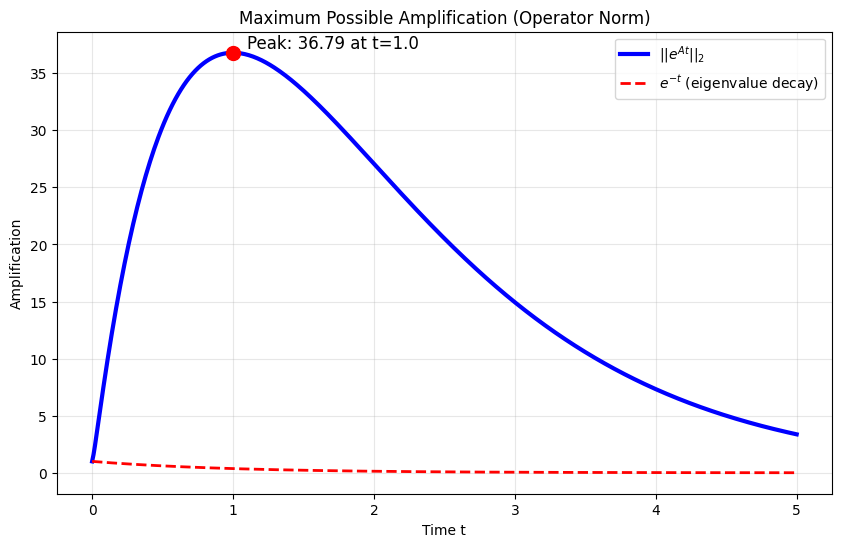

In [2]:
# Compute maximum amplification G(t) = ||e^{At}||_2
def G_t(t):
    # Singular values of e^{At}
    M = exp_At(t)
    sigma = np.linalg.svd(M, compute_uv=False)
    return sigma[0]  # Largest singular value

G_values = [G_t(ti) for ti in t]

plt.figure(figsize=(10, 6))
plt.plot(t, G_values, 'b-', linewidth=3, label=r'$||e^{At}||_2$')
plt.plot(t, np.exp(-t), 'r--', linewidth=2,
         label=r'$e^{-t}$ (eigenvalue decay)')

# Mark the maximum
t_peak = 1.0
G_max = G_t(t_peak)
plt.plot(t_peak, G_max, 'ro', markersize=10)
plt.text(t_peak+0.1, G_max, f'Peak: {G_max:.2f} at t={t_peak}',
         fontsize=12, verticalalignment='bottom')

plt.xlabel('Time t')
plt.ylabel('Amplification')
plt.title('Maximum Possible Amplification (Operator Norm)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Phase Space Trajectories

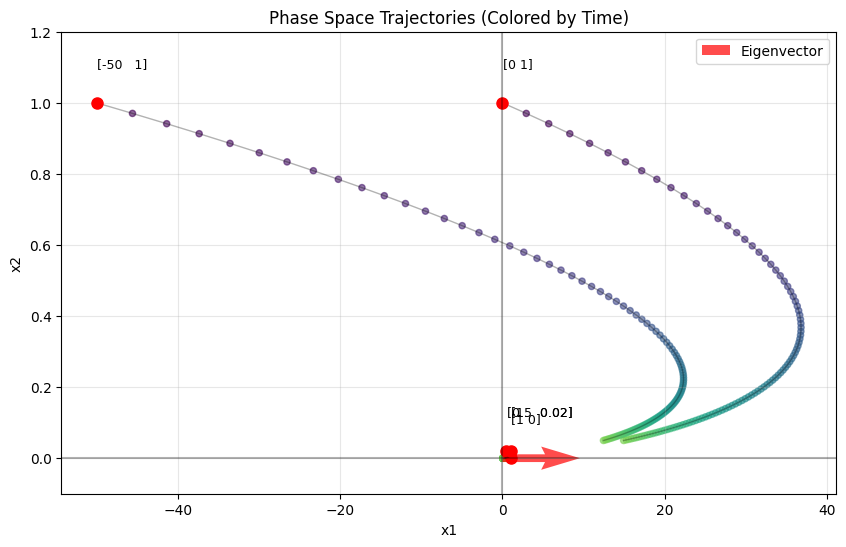

In [25]:
plt.figure(figsize=(10, 6))

# Plot trajectories in phase space
for x0 in initial_conditions:
    x1_vals = []
    x2_vals = []
    for tj in t:
        x_t = exp_At(tj) @ x0
        x1_vals.append(x_t[0])
        x2_vals.append(x_t[1])

    # Color by time (darker = later)
    colors = plt.cm.viridis(np.linspace(0, 0.8, len(x1_vals)))
    plt.scatter(x1_vals, x2_vals, c=colors, s=20, alpha=0.6)
    plt.plot(x1_vals, x2_vals, 'k-', alpha=0.3, linewidth=1)

    # Mark initial point
    plt.plot(x0[0], x0[1], 'ro', markersize=8)
    plt.text(x0[0]+0.1, x0[1]+0.1, f'{x0}', fontsize=9)

# Plot eigenvectors (both are [1,0] since matrix is defective)
plt.quiver(0, 0, 1, 0, color='r', scale=10,
           width=0.01, label='Eigenvector', alpha=0.7)

plt.axhline(y=0, color='k', alpha=0.3)
plt.axvline(x=0, color='k', alpha=0.3)
plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Phase Space Trajectories (Colored by Time)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.ylim(-.1, 1.2)
plt.show()

## 3D Visualization: Norm vs Time vs Initial Angle

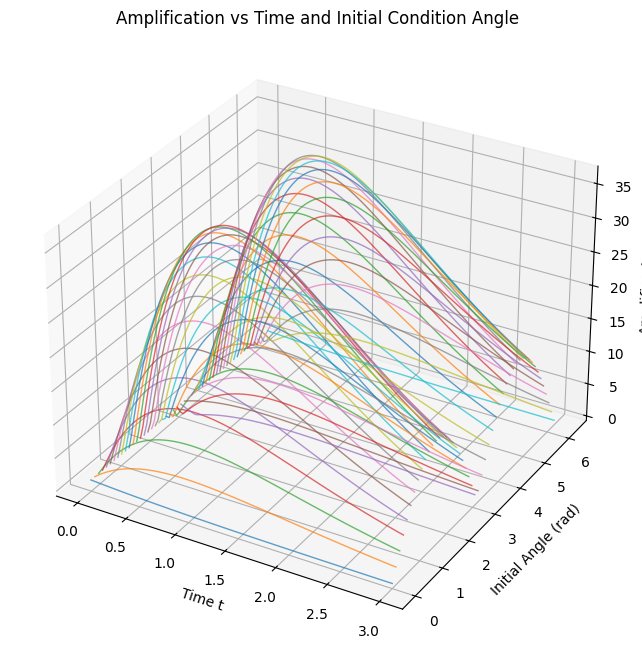

In [4]:
from mpl_toolkits.mplot3d import Axes3D

# Vary initial angle
angles = np.linspace(0, 2*np.pi, 50)
t = np.linspace(0, 3, 100)

amplification = np.zeros((len(angles), len(t)))

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

for i, theta in enumerate(angles):
    x0 = np.array([np.cos(theta), np.sin(theta)])
    for j, tj in enumerate(t):
        x_t = exp_At(tj) @ x0
        amplification[i, j] = np.linalg.norm(x_t)

    ax.plot(t, theta*np.ones_like(t), amplification[i, :],
            alpha=0.7, linewidth=1)

ax.set_xlabel('Time t')
ax.set_ylabel('Initial Angle (rad)')
ax.set_zlabel('Amplification')
ax.set_title('Amplification vs Time and Initial Condition Angle')
plt.show()

## Energy Growth Rate at t=0

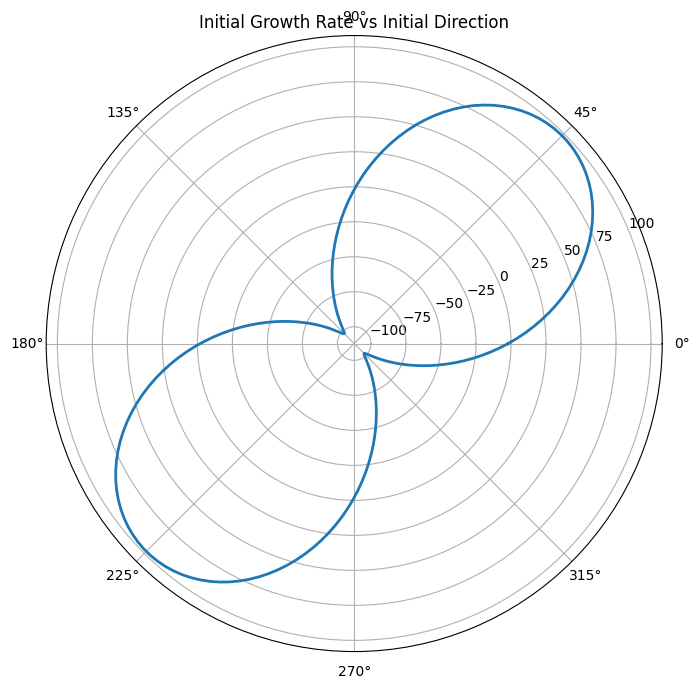

In [5]:
# Derivative of squared norm at t=0
theta = np.linspace(0, 2*np.pi, 200)
growth_rate = []

for th in theta:
    x0 = np.array([np.cos(th), np.sin(th)])
    # d/dt(||x||^2) at t=0 = x0^T (A^T + A) x0
    growth = x0.T @ (A.T + A) @ x0
    growth_rate.append(growth)

plt.figure(figsize=(8, 8))
plt.polar(theta, growth_rate, linewidth=2)
plt.title('Initial Growth Rate vs Initial Direction')
plt.grid(True)
plt.show()

Interpretation of the Plots:

1. Norm vs Time: Shows that some initial conditions lead to significant growth (peaking around t=1) before decaying. The red dashed line shows what pure eigenvalue decay would predict.
2. Maximum Amplification Curve: The blue curve shows the worst-case amplification possible at each time. It peaks at ~36.79 at t=1, meaning there exists an initial condition that grows by this factor before decaying.
3. Phase Space Trajectories: Shows how states spiral outward initially before converging to the origin. The colors show time evolution (blue→yellow).
4. 3D Plot: Demonstrates how different initial directions lead to different amplification patterns.
5. Polar Plot: Shows the initial growth rate as a function of initial angle. Positive values indicate initial growth.

Key Visual Observations:

- Non-monotonic decay: Unlike what eigenvalues (-1) suggest, the norm doesn't decay monotonically.
- Directional sensitivity: Growth depends critically on the initial direction.
- Peak amplification: Occurs around t=1, not at t=0.
- Eventual stability: All trajectories eventually converge to zero (asymptotic stability).

These plots clearly illustrate why eigenvalue analysis alone is insufficient for understanding short-term behavior in non-normal systems. The transient growth can be orders of magnitude larger than what eigenvalues predict!